# Importando bibliotecas e Dados

## Importação de Dados
Os dados serão importados através do conjunto **dados.csv**, que foi extraído usando o código **Guarda Dados COM**. Os dados são importados sem o nome das colunas, e a primeira coluna é o index.

In [12]:
# importação da biblioteca de dataframes e análise de dados
import pandas as pd
# importação da biblioteca de gráficos
import numpy as np
# importação de biblioteca para manipulação de arquivos
from pathlib import Path
import os
# importação da biblioteca de gráficos
import matplotlib.pyplot as plt
# importação da biblioteca de regressão logística
from sklearn.linear_model import LogisticRegression
# Voting Classifier (Ensenble Learning)
from sklearn.ensemble import VotingClassifier
# Matriz confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, f1_score, precision_score

# Importação de Dados

Existem três conjunto de dados ``dados1.csv``, ``dados2.csv``, ``dados3.csv``, ``dados4.csv``, ``dados5.csv`` que foram coletados. Esses conjuntos de dados foram gerados através de simulações do consumo de **bateria** e da **qualidade do sinal**, sendo o último um valor aleatório de qualidade. O intuito de se construir 3 conjuntos de dados para análise, é de que seja possível, em algumas das análises feitas, juntá-los para realizar uma análise do comportamento _"médio"_, ou melhor, do comportamento real do controlador fuzzy. Em algumas análises, ao utilizar apenas um conjunto de dados, como a entrada **qualidade do sinal** é aleatória, pode haver situações em que o comportamento do controlador fuzzy _"real"_ não é traduzido corretamente. Portanto, é necessário integrar os conjuntos em um só, para obter essa análise _"real"_. 

In [13]:
## Dados a serem analisados
DIRETORIO = Path('../Data')
DATA_FRAMES = []

In [14]:
def load_data (dir):

    """ 
        Lê todos os csv presente no diretório e salva os arquivos em uma lista de dataframes

        dir -> diretório dos dados (type: path)
        dfs -> lista contendo todo o conjunto de dados (type: list)
    """
    
    dfs=[]

    name_columns = [
        'Index', 'Regra1_1', 'Regra1_2', 'Regra1_3', 'Regra1_4', 'Regra2_1', 'Regra2_2', 
        'Regra2_3', 'Regra2_4', 'Regra3_1', 'Regra3_2', 'Regra3_3', 'Regra3_4', 'Regra4_1', 
        'Regra4_2', 'Regra4_3', 'Regra4_4', 'Regra5_1', 'Regra5_2', 'Regra5_3', 'Regra5_4', 
        'Bateria', 'Taxa', 'PertinenciaLiga', 'PertinenciaNaoLiga', 'Saida', 'Class_saida'
    ]

    # Integração dos loops
    for arquivo in dir.glob('*.csv'):
        if arquivo.is_file():
            # O objeto 'arquivo' do pathlib já contém o caminho completo
            # Lemos o CSV e adicionamos diretamente à lista
            df = pd.read_csv(arquivo, header=None, names=name_columns, index_col='Index')
            dfs.append(df)

    print(f"Total de {len(dfs)} arquivos carregados com sucesso.")
    return dfs

In [15]:
DATA_FRAMES = load_data(DIRETORIO)

Total de 5 arquivos carregados com sucesso.


In [16]:
DATA_FRAMES[0].head()

,Regra1_1,Regra1_2,Regra1_3,Regra1_4,Regra2_1,Regra2_2,Regra2_3,Regra2_4,Regra3_1,Regra3_2,...,Regra5_1,Regra5_2,Regra5_3,Regra5_4,Bateria,Taxa,PertinenciaLiga,PertinenciaNaoLiga,Saida,Class_saida
Index,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,100.00,93,1.00,0.0,72.00,1
1,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,99.67,67,0.50,0.0,66.92,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,99.33,29,0.00,1.0,28.00,0
3,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,99.00,74,0.77,0.0,69.98,1
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,98.66,93,1.00,0.0,72.00,1


In [17]:
DATA_FRAMES[0].describe()

,Regra1_1,Regra1_2,Regra1_3,Regra1_4,Regra2_1,Regra2_2,Regra2_3,Regra2_4,Regra3_1,Regra3_2,...,Regra5_1,Regra5_2,Regra5_3,Regra5_4,Bateria,Taxa,PertinenciaLiga,PertinenciaNaoLiga,Saida,Class_saida
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,...,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,0.118243,0.094595,0.033784,0.094595,0.131757,0.104730,0.030405,0.091216,0.162162,0.104730,...,0.209459,0.172297,0.087838,0.141892,50.668919,50.530405,0.449797,0.375608,52.474628,0.567568
std,0.323443,0.293150,0.180978,0.293150,0.338799,0.306723,0.171991,0.288404,0.369224,0.306723,...,0.407612,0.378278,0.283538,0.349530,28.626274,30.440146,0.374805,0.412723,18.940892,0.496253
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.340000,0.000000,0.000000,0.000000,28.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,26.005000,22.000000,0.000000,0.000000,29.982500,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,50.670000,54.000000,0.550000,0.030000,66.920000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,75.335000,77.000000,0.770000,0.792500,69.762500,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,100.000000,96.000000,1.000000,1.000000,72.000000,1.000000


# Análise do Controlador Fuzzy
## Regras de Ativação
Será feito a contagem de ativação das regras que compõem o controlador fuzzy. Essa informação poderá ser útil para identificar regras possivelmente inúteis, equivalentes e sobressalentes.

In [18]:
# Criando DataFrames que contém apenas informações das funções de Ativação do controlador Fuzzy
def data_rules(df):

    """
        Cria lista de dataframes com apenas as colunas referentes à regras de ativação

        df_rules -> lista de dataframe desses conjuntos de dados
        rules_columns -> nomes das colunas eliminadas
    """

    df_rules = []

    rules_columns = ['Bateria','Taxa','PertinenciaLiga','PertinenciaNaoLiga','Saida','Class_saida']

    for data in DATA_FRAMES:
        df_rules.append(data.drop(rules_columns, axis=1).copy())
    
    return df_rules


In [19]:
DATA_RULES = data_rules(DATA_FRAMES)

def concat_intern_dfs (dfs):
    dfs_c = pd.concat([dfs[0], dfs[1], dfs[2], dfs[3], dfs[4]],ignore_index=True)
    return dfs_c

DATA_RULES_C = concat_intern_dfs(DATA_RULES)

In [20]:
DATA_RULES_C

,Regra1_1,Regra1_2,Regra1_3,Regra1_4,Regra2_1,Regra2_2,Regra2_3,Regra2_4,Regra3_1,Regra3_2,Regra3_3,Regra3_4,Regra4_1,Regra4_2,Regra4_3,Regra4_4,Regra5_1,Regra5_2,Regra5_3,Regra5_4
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1476,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1477,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1478,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


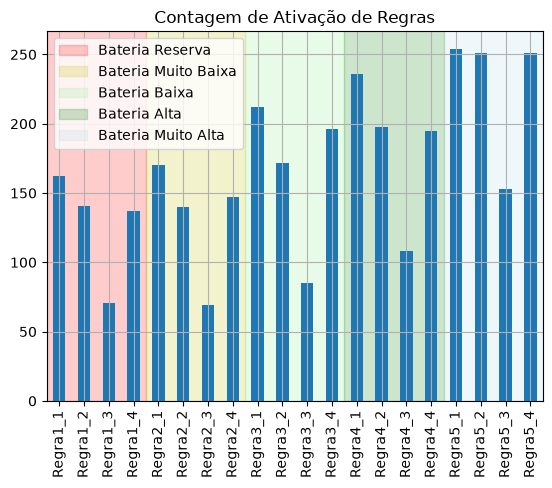

In [21]:
# Soma todas as ativações para cada função
sr_rules_sum = DATA_RULES_C.sum()

# Área do gráfico que representa os estados da bateria
plt.axvspan(-0.5, 3.5, color='red', alpha=0.2, label='Bateria Reserva')
plt.axvspan(3.5, 7.5, color='y', alpha=0.2, label='Bateria Muito Baixa')
plt.axvspan(7.5, 11.5, color='lightgreen', alpha=0.2, label='Bateria Baixa')
plt.axvspan(11.5, 15.5, color='green', alpha=0.2, label='Bateria Alta')
plt.axvspan(15.5, 19.5, color='lightblue', alpha=0.2, label='Bateria Muito Alta')

# Plota o gráfico de barras das funções de ativação
sr_rules_sum.plot(kind='bar',title='Contagem de Ativação de Regras', grid=True)

# Altera a localização da Legenda
plt.legend(loc='upper left', ncol=1)

## Avaliação da Saída do Controlador

In [22]:
# Guarda as colunas que contém a string "Regras"

def data_results(dfs):
    """
        Cria lista de dataframes com apenas as colunas referentes à resultados do controlador Fuzzy

        df_results -> lista de dataframe desses conjuntos de dados
        rules_columns -> nomes das colunas eliminadas
    """
    
    df_results = []

    for data in dfs:
        # Identifica as colunas de regras para cada DataFrame individualmente (mais seguro)
        rules_columns = [col for col in data.columns if col.startswith('Regra')]
        
        # Remove as colunas e adiciona a cópia à lista
        # Note que axis=1 está dentro do drop()
        df_limpo = data.drop(columns=rules_columns).copy()
        df_results.append(df_limpo)
    
    return df_results

In [23]:
DATA_RESULTS_C = concat_intern_dfs(data_results(DATA_FRAMES))

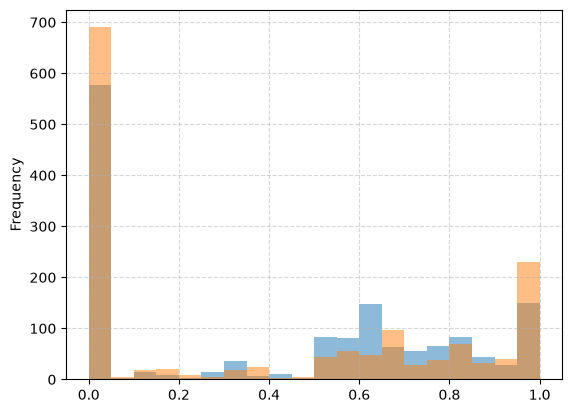

In [24]:
DATA_RESULTS_C['PertinenciaLiga'].plot(kind='hist', bins=20, label='Pertinência Liga', alpha=0.5)
DATA_RESULTS_C['PertinenciaNaoLiga'].plot(kind='hist', bins=20, label='Pertinência Não Liga', alpha=0.5)
plt.grid('on', alpha=0.5, linestyle='--')

O gráfico sugere que existem muitos casos de certezas absolutas no processo de decisão do controlador Fuzzy (valores de pertinência 0 ou 1). Esses casos parecem ser superiores aos casos em que o controlador teve que realizar uma "avaliação" entre pertinências para produzir a saída. Para isso, plota-se o seguinte gráfico adotando:
$$μ = Pertinência_{saída}$$

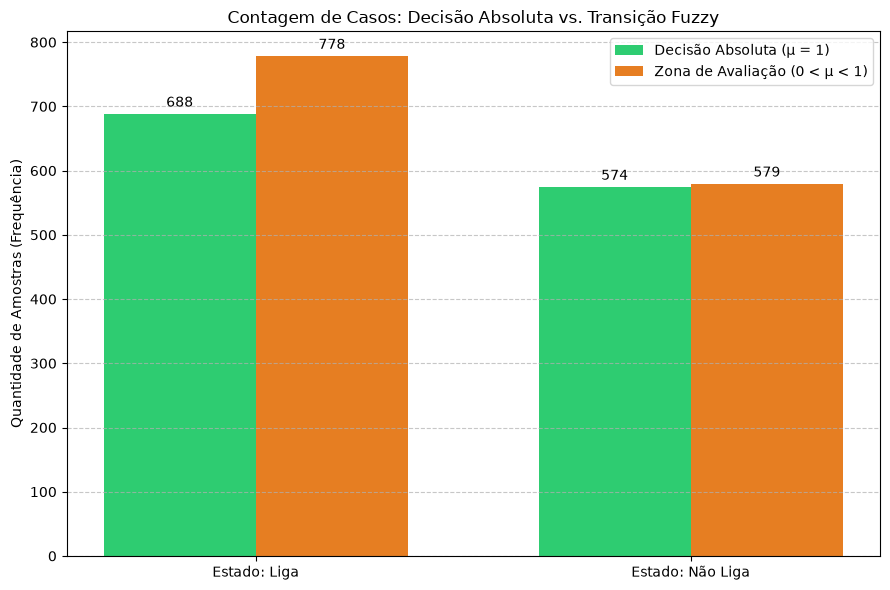

In [25]:
# 1. Calculando a contagem (quantidade de vezes) de cada caso
# Adicionados parênteses para garantir a lógica correta e evitar erros de precedência
abs_liga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaLiga'] == 1) | (DATA_RESULTS_C['PertinenciaNaoLiga'] == 0)].shape[0]
abs_nliga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaNaoLiga'] == 1) | (DATA_RESULTS_C['PertinenciaLiga'] == 0)].shape[0]

# Casos de Transição/Avaliação (Pertinência entre 0 e 1)
aval_liga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaLiga'] > 0) & (DATA_RESULTS_C['PertinenciaLiga'] < 1)].shape[0]
aval_nliga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaNaoLiga'] > 0) & (DATA_RESULTS_C['PertinenciaNaoLiga'] < 1)].shape[0]

# 2. Organização dos dados
labels = ['Estado: Liga', 'Estado: Não Liga']
contagens_absolutas = [abs_liga, abs_nliga]
total_absolutas = sum(contagens_absolutas)

contagens_transicao = [aval_liga, aval_nliga]
total_transicao = sum(contagens_transicao)

x = [0, 1]  # Posições no eixo X
width = 0.35 

# 3. Criação do Gráfico
fig, ax = plt.subplots(figsize=(9, 6))

# Cálculo da posição das barras para ficarem lado a lado corretamente
rects1 = ax.bar([p - width/2 for p in x], contagens_absolutas, width, 
                label='Decisão Absoluta (μ = 1)', color='#2ecc71')
rects2 = ax.bar([p + width/2 for p in x], contagens_transicao, width, 
                label='Zona de Avaliação (0 < μ < 1)', color='#e67e22')

# 4. Customização e Estética
ax.set_ylabel('Quantidade de Amostras (Frequência)')
ax.set_title('Contagem de Casos: Decisão Absoluta vs. Transição Fuzzy')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Adicionando os rótulos numéricos sobre as barras
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:
print(f"Porcentagem de Casos Absolutos: {total_absolutas / (total_absolutas + total_transicao) * 100:.2f}%\nPorcentagem de Casos de Transição: {total_transicao / (total_absolutas + total_transicao) * 100:.2f}%")
print(f"Polarização de Decisão: {total_absolutas / total_transicao:.2f}")

Porcentagem de Casos Absolutos: 48.19%
Porcentagem de Casos de Transição: 51.81%
Polarização de Decisão: 0.93


Nota-se que o sistema está muito próximo do equilíbrio entre casos de certeza absoluta e casos de transição (ou avaliação). A métrica `Polarização de Decisão` indica uma característica de decisão do modelo: 

* quanto próxima de `1`, o modelo está equilibrando as decisões absolutas e as avaliações
* quando próxima de `0`, o modelo não possui nenhuma certeza nas decisões
* quando maior que `1`, o modelo está muito confiante na decisão

> Quanto mais equilibrado, melhor o modelo se comporta. Essa métrica pode ser usada similarmente a identificação de casos de underfitting e overfitting de modelos ajustáveis. Nesse caso, indicará se as regras de ativação estão equilibradas em relação aos resultados que se deseja atingir.

## Curva de Taxa de Classificação Fuzzy
Com o intuito de visualizar o comportamento do sistema (ligar ou não ligar o sistema) em relação à bateria, será necessário criar uma taxa usando média ponderada de um intervalo de valores:

$$y_t = \frac{1}{k} \sum_{i=t - \lfloor k/2 \rfloor}^{t + \lfloor k/2 \rfloor} x_i$$

No caso em que $k = 25$:

$$y_t = \frac{x_{t-12} + x_{t-11} + \dots + x_t + \dots + x_{t+11} + x_{t+12}}{25}$$

Esse intervalo deve ser suficientemente grande para produzir uma curva suavizada, e suficientemente pequeno para não aumentar o lag causado pelo cálculo dessa média. O lag é calculado por:

$$Lag = \frac{n - 1}{2}$$

Usando 25 pontos, o Lag será de 12 pontos, mas a curva será suavizada de forma que a visualização do comportamento não seja tão comprometida. O Lag será perceptível nas extremidades do gráfico (ausencia de informação).

Como a o sistema usa a qualidade do sinal para realizar decisões, e essa qualidade é aleatória na simulação, existirá pontos em que a taxa de classificação fuzzy será muito baixa em pontos que poderiam ser altos. Portanto, será necessário usar diversos conjuntos de dados em resposta ao sistema, traçar essas linhas e realizar a média delas. É possível obter mais informações sobre o modelo usando o desvio padrão entre essas linhas.

O desvio padrão demonstra os casos onde o modelo apresenta muita incerteza sobre qual decisão tomar, provavelmente devido a valores de saída em que Liga e Não Liga possuem os mesmos valores.

In [27]:
DATA_RESULTS = data_results(DATA_FRAMES)

In [28]:
# Filtra apenas as colunas Bateria e Saída 
def data_results_BS(data_results_list):
    
    """
        Cria lista de dataframes com apenas as colunas referentes à Bateria e Saída do controlador Fuzzy

        data_results_list -> lista de dataframe desses conjuntos de dados
    """

    for i, df in enumerate(data_results_list):
        data_results_list[i] = df.drop(['Taxa', 'PertinenciaLiga', 'PertinenciaNaoLiga', 'Saida'], axis=1)
    
    return data_results_list

In [29]:
DATA_RESULTS_BS = data_results_BS(DATA_RESULTS)

In [30]:
DATA_RESULTS_BS[0]

,Bateria,Class_saida
Index,,
0,100.00,1
1,99.67,1
2,99.33,0
3,99.00,1
4,98.66,1
...,...,...
291,2.68,0
292,2.34,1
293,2.01,0


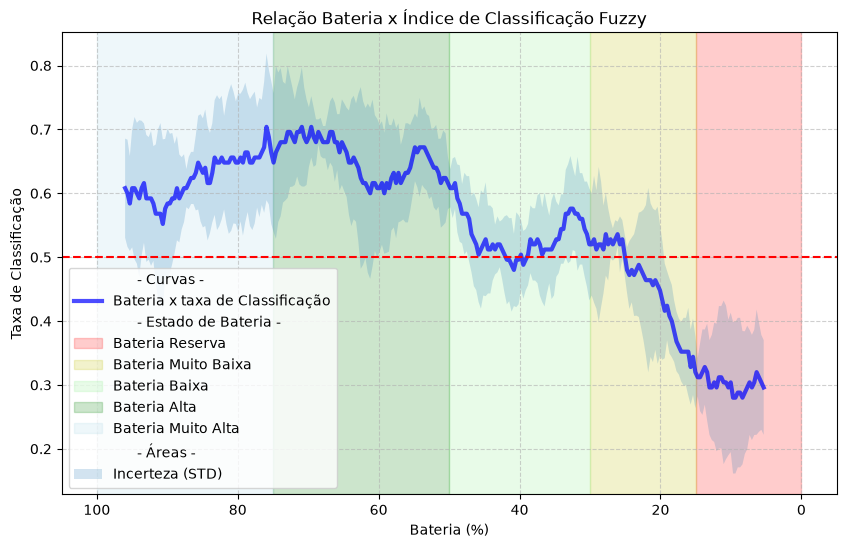

In [31]:
# --- 1. PROCESSAMENTO DOS DADOS ---

# Otimização: Aplicamos a média móvel (rolling) e dropna em todos os DFs da lista via List Comprehension
# Em seguida, já preparamos cada DF para a concatenação (set_index e seleção da coluna alvo)
processed_rates = [
    df.rolling(window=25, center=True).mean()
      .set_index('Bateria')['Class_saida'] 
    for df in DATA_RESULTS_BS
]

# Concatenamos todos os resultados em um único DataFrame (cada DF vira uma coluna)
batery_class_rate_f = pd.concat(processed_rates, axis=1)

# Calculamos as estatísticas por linha (axis=1) para gerar a curva média e a área de sombra
batery_class_rate_f['media'] = batery_class_rate_f.mean(axis=1)
batery_class_rate_f['std'] = batery_class_rate_f.std(axis=1)

# --- 2. PLOTAGEM ---

plt.figure(figsize=(10, 6))

# Títulos decorativos na legenda
plt.plot([], [], ' ', label='      - Curvas -')

# Curva principal (Média)
plt.plot(batery_class_rate_f.index, batery_class_rate_f['media'], 
         label='Bateria x taxa de Classificação', alpha=0.7, color='blue', linewidth=3)

plt.plot([], [], ' ', label='      - Estado de Bateria -')

# Faixas coloridas para estados de bateria
# Nota: axvspan preenche o fundo de acordo com os limites definidos
plt.axvspan(0, 15, color='red', alpha=0.2, label='Bateria Reserva')
plt.axvspan(15, 30, color='y', alpha=0.2, label='Bateria Muito Baixa')
plt.axvspan(30, 50, color='lightgreen', alpha=0.2, label='Bateria Baixa')
plt.axvspan(50, 75, color='green', alpha=0.2, label='Bateria Alta')
plt.axvspan(75, 100, color='lightblue', alpha=0.2, label='Bateria Muito Alta')

plt.plot([], [], ' ', label='      - Áreas -')

# Preenchimento da área de desvio padrão (Incerteza)
plt.fill_between(batery_class_rate_f.index, 
                 batery_class_rate_f['media'] - batery_class_rate_f['std'], 
                 batery_class_rate_f['media'] + batery_class_rate_f['std'], 
                 alpha=0.2, label='Incerteza (STD)')

# Ajustes finos de escala e eixos
plt.gca().invert_xaxis()  # Inverte o eixo X (comum em gráficos de descarga)
plt.title('Relação Bateria x Índice de Classificação Fuzzy')
plt.xlabel('Bateria (%)')
plt.ylabel('Taxa de Classificação')

# Posicionamento da legenda
plt.legend(loc='lower left', ncol=1)

plt.axhline(y=0.5, color='red', linestyle='--', label='Limiar de Decisão')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [32]:
avg_std = batery_class_rate_f['std'].mean()
print(f"Desvio padrão médio: {avg_std:.2f}")

Desvio padrão médio: 0.08


# Machine Learning (Otimização de modelo)

## Transformação do Controlador Fuzzy - Regressão Logística

De certa forma nosso controlador fuzzy funciona como um modelo classificador binário: 0 (Não Liga) ou 1 (Liga). É possível ajustar uma regressão logística para simplificar e otimizar o modelo, possibilitando a integração do mesmo em outras linguagem de programação, sem que haja necessidade de transpor toda a configuração do controlador fuzzy feita. 

## Importação de Bibliotecas para Regressão Logística

In [74]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, brier_score_loss
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from tqdm.auto import tqdm

d:\Projetos\Simulador-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Voting Classifier

In [34]:
DATA_RESULTS = data_results(DATA_FRAMES)

def train_split (df_list, df_index):
    """
        Função para separar os dados de treino em x e y

        df_list -> lista de dataframes (type: list)
        df_index -> índice do dataframe a ser usado como validação/teste (type: int)
    """
    X = df_list[df_index][['Bateria', 'Taxa']]
    y = df_list[df_index]['Class_saida']

    return X, y

df_trains = [train_split(DATA_RESULTS, i) for i in range(4)]

df_teste = DATA_RESULTS[4]
X_teste = df_teste[['Bateria', 'Taxa']]
y_teste = df_teste['Class_saida']

In [35]:
LOG_REGS = [LogisticRegression(max_iter=100),
            LogisticRegression(max_iter=200), 
            LogisticRegression(max_iter=300), 
            LogisticRegression(max_iter=400)]

DEC_TREES = [DecisionTreeClassifier(max_depth=10, random_state=42), 
             DecisionTreeClassifier(max_depth=30, random_state=42), 
             DecisionTreeClassifier(max_depth=60, random_state=42),
             DecisionTreeClassifier(max_depth=100, random_state=42)]

DEC_ESTIMATORS = []
LOG_ESTIMATORS = []

# 1. Adiciona os modelos de Regressão Logística
for idx, model in enumerate(LOG_REGS):
    LOG_ESTIMATORS.append((f'lr{idx+1}', model))

# 2. Adiciona os modelos de Árvore de Decisão
for idx, model in enumerate(DEC_TREES):
    DEC_ESTIMATORS.append((f'dt{idx+1}', model))

DEC_VOTE_MODEL = VotingClassifier(estimators=DEC_ESTIMATORS, voting='soft')
REG_VOTE_MODEL = VotingClassifier(estimators=LOG_ESTIMATORS, voting='soft')



In [94]:
def train_cal_models(df_trains, model, tqdm):
    """
        Treina os modelos de classificação com os dados de treino fornecidos.

        df_trains -> lista de tuplas contendo (X_train, y_train) para cada conjunto de treino
        model -> modelo de classificação a ser treinado (type: sklearn classifier)
    """

    trained_models = []
    reports = []
    
    for i, (X_train, y_train) in enumerate(df_trains):
        # calibração do modelo para melhorar a probabilidade de previsão
        model = CalibratedClassifierCV(model, cv=5, method='sigmoid')
        trained_model = model.fit(X_train, y_train)
        trained_models.append(trained_model)
        
        # Avaliação do modelo no conjunto de teste
        y_pred = trained_model.predict(X_teste)
        class_report = classification_report(y_teste, y_pred, output_dict=True)['0']
        reports.append(class_report)
        tqdm.update(1)
    
    return trained_models, reports

In [93]:
def train_models (df_trains, models, tqdm):

    trained_models = []
    reports = []
   
    for i, (X_train, y_train) in enumerate(df_trains):
        trained_model = models[i].fit(X_train, y_train)
        trained_models.append(trained_model)

        # Avaliação do modelo no conjunto de teste
        y_pred = trained_model.predict(X_teste)
        class_report = classification_report(y_teste, y_pred, output_dict=True)['0']
        reports.append(class_report)
        tqdm.update(1)

    return trained_models, reports


In [95]:
with tqdm(total=16, desc="Cronograma de Treinamento Geral") as pbar:

    pbar.set_postfix_str("Rodando: REG_VOTE_MODELS")
    TRAIN_REG_VOTE_MODELS, TRAIN_REG_VOTE_MODELS_REPORT= train_cal_models(df_trains, REG_VOTE_MODEL, pbar)
    pbar.set_postfix_str("Rodando: DEC_VOTE_MODELS")
    TRAIN_DEC_VOTE_MODELS, TRAIN_DEC_VOTE_MODELS_REPORT = train_cal_models(df_trains, DEC_VOTE_MODEL, pbar)
    pbar.set_postfix_str("Rodando: LOG_REGS")
    TRAIN_REG_MODELS, TRAIN_REG_MODELS_REPORT = train_models(df_trains, LOG_REGS, pbar)
    pbar.set_postfix_str("Rodando: DEC_TREES")
    TRAIN_DEC_MODELS, TRAIN_DEC_MODELS_REPORT = train_models(df_trains, DEC_TREES, pbar)

Cronograma de Treinamento Geral: 100%|██████████| 16/16 [00:44<00:00,  2.79s/it, Rodando: DEC_TREES]     


In [97]:
import pandas as pd

def gerar_tabela_metricas_completa(relatorios_agrupados):
    """
    relatorios_agrupados -> dicionário onde a chave é o nome do grupo 
                            e o valor é a LISTA de relatórios retornada pelas funções.
    """
    dados_tabela = []
    
    for nome_grupo, lista_reports in relatorios_agrupados.items():
        for i, report in enumerate(lista_reports):
            linha = {
                "Grupo": nome_grupo,
                "Modelo_ID": i, # Índice do modelo dentro da lista
                "Precision": report.get("precision"),
                "Recall": report.get("recall"),
                "F1-Score": report.get("f1-score"),
                "Support": report.get("support")
            }
            dados_tabela.append(linha)
            
    return pd.DataFrame(dados_tabela)

In [98]:
# Agora que as funções retornam listas:
relatorios_totais = {
    "REG_VOTE_MODELS": TRAIN_REG_VOTE_MODELS_REPORT,
    "DEC_VOTE_MODELS": TRAIN_DEC_VOTE_MODELS_REPORT,
    "LOG_REGS": TRAIN_REG_MODELS_REPORT,
    "DEC_TREES": TRAIN_DEC_MODELS_REPORT
}

# Gera a tabela detalhada com todos os modelos
df_completo = gerar_tabela_metricas_completa(relatorios_totais)
display(df_completo)

,Grupo,Modelo_ID,Precision,Recall,F1-Score,Support
0,REG_VOTE_MODELS,0,0.958904,0.985915,0.972222,142.0
1,REG_VOTE_MODELS,1,0.965278,0.978873,0.972028,142.0
2,REG_VOTE_MODELS,2,0.958042,0.964789,0.961404,142.0
3,REG_VOTE_MODELS,3,0.977941,0.936620,0.956835,142.0
4,DEC_VOTE_MODELS,0,1.000000,0.978873,0.989324,142.0
5,DEC_VOTE_MODELS,1,1.000000,0.992958,0.996466,142.0
6,DEC_VOTE_MODELS,2,0.979310,1.000000,0.989547,142.0
7,DEC_VOTE_MODELS,3,0.979310,1.000000,0.989547,142.0
8,LOG_REGS,0,0.958904,0.985915,0.972222,142.0
9,LOG_REGS,1,0.965035,0.971831,0.968421,142.0


In [99]:
def selecionar_melhores_modelos(df_metricas, dicionario_modelos_treinados, metrica="F1-Score"):
    """
    Seleciona o melhor modelo de cada grupo com base em uma métrica e 
    os armazena em um dicionário.
    
    df_metricas -> DataFrame gerado pela função anterior (contém Grupo, Modelo_ID, etc.)
    dicionario_modelos_treinados -> Dicionário onde a chave é o nome do grupo 
                                    e o valor é a LISTA de modelos treinados.
    metrica -> Nome da coluna a ser maximizada (ex: "F1-Score", "Precision", "Recall")
    """
    melhores_modelos = {}
    
    # Agrupa o DataFrame por grupo de modelos
    for grupo, grupo_df in df_metricas.groupby("Grupo"):
        # Encontra o índice da linha que possui o maior valor para a métrica escolhida
        melhor_linha = grupo_df.loc[grupo_df[metrica].idxmax()]
        
        # Pega o índice (ID) daquele modelo específico dentro da lista do grupo
        melhor_idx = int(melhor_linha["Modelo_ID"])
        
        # Armazena o objeto do modelo correspondente no dicionário
        melhores_modelos[grupo] = dicionario_modelos_treinados[grupo][melhor_idx]
        
        print(f"Melhor modelo para '{grupo}' selecionado (ID: {melhor_idx}) com {metrica}: {melhor_linha[metrica]:.4f}")
        
    return melhores_modelos

In [100]:
# 1. Agrupa os modelos treinados em um dicionário
todos_os_modelos_treinados = {
    "REG_VOTE_MODELS": TRAIN_REG_VOTE_MODELS,
    "DEC_VOTE_MODELS": TRAIN_DEC_VOTE_MODELS,
    "LOG_REGS": TRAIN_REG_MODELS,
    "DEC_TREES": TRAIN_DEC_MODELS
}

# 2. Executa a função escolhendo a métrica de referência (ex: "F1-Score")
dict_melhores_modelos = selecionar_melhores_modelos(df_completo, todos_os_modelos_treinados, metrica="F1-Score")

# Exemplo de como acessar um dos melhores modelos salvos:
melhor_dec_tree = dict_melhores_modelos["DEC_TREES"]

Melhor modelo para 'DEC_TREES' selecionado (ID: 1) com F1-Score: 1.0000
Melhor modelo para 'DEC_VOTE_MODELS' selecionado (ID: 1) com F1-Score: 0.9965
Melhor modelo para 'LOG_REGS' selecionado (ID: 0) com F1-Score: 0.9722
Melhor modelo para 'REG_VOTE_MODELS' selecionado (ID: 0) com F1-Score: 0.9722


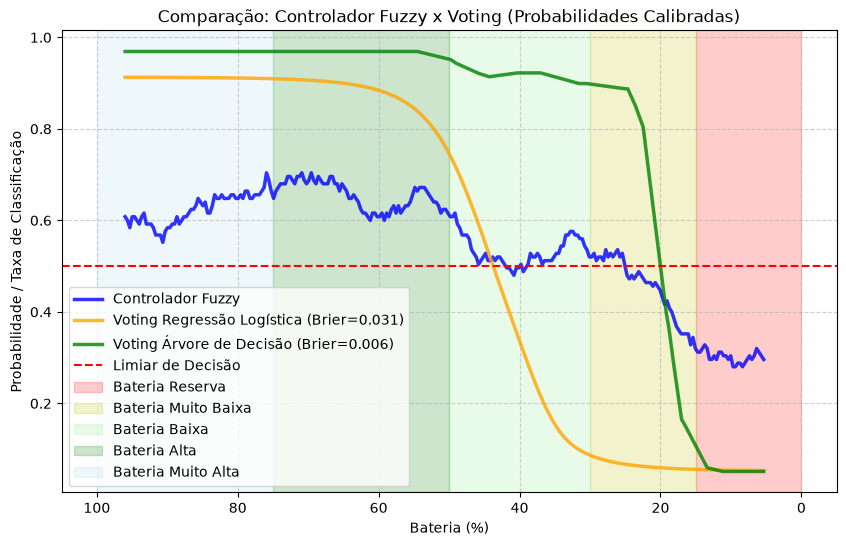

In [101]:
reg_trained = dict_melhores_modelos["REG_VOTE_MODELS"]
dec_trained = dict_melhores_modelos["DEC_VOTE_MODELS"]

y_pred_log = reg_trained.predict(X_teste)  # validação do modelo de voting de regressão logística
y_pred_tree = dec_trained.predict(X_teste)  # validação do modelo de voting de árvore de decisão

log_acc = accuracy_score(y_teste, y_pred_log)
log_prec = precision_score(y_teste, y_pred_log, zero_division=0)
log_rec = recall_score(y_teste, y_pred_log, zero_division=0)
log_f1 = f1_score(y_teste, y_pred_log, zero_division=0)

tree_acc = accuracy_score(y_teste, y_pred_tree)
tree_prec = precision_score(y_teste, y_pred_tree, zero_division=0)
tree_rec = recall_score(y_teste, y_pred_tree, zero_division=0)
tree_f1 = f1_score(y_teste, y_pred_tree, zero_division=0)

log_label = (
    f"Voting Regressão Logística"
)
tree_label = (
    f"Voting Árvore de Decisão"
)

# Curva comparativa entre controlador fuzzy, regressão logística e árvore de decisão
# Recriando a curva fuzzy para comparação visual
processed_rates = [
    df.rolling(window=25, center=True).mean().set_index('Bateria')['Class_saida']
    for df in DATA_RESULTS_BS
]

batery_class_rate_f = pd.concat(processed_rates, axis=1)
batery_class_rate_f['media'] = batery_class_rate_f.mean(axis=1)

# Gerando curvas de probabilidade para os VotingClassifier calibrados sobre o mesmo eixo de bateria
bateria_grid = np.linspace(batery_class_rate_f.index.min(), batery_class_rate_f.index.max(), 250)
taxa_media = pd.concat([df[['Taxa']] for df in DATA_RESULTS], ignore_index=True)['Taxa'].mean()
X_grid = pd.DataFrame({'Bateria': bateria_grid, 'Taxa': taxa_media})

# Probabilidades usando os modelos calibrados treinados (reg_trained, dec_trained)
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

probs_reg = reg_trained.predict_proba(X_grid)[:, 1]
probs_dec = dec_trained.predict_proba(X_grid)[:, 1]

# Brier score no conjunto de teste para controlar calibração
brier_reg = brier_score_loss(y_teste, reg_trained.predict_proba(X_teste)[:, 1])
brier_dec = brier_score_loss(y_teste, dec_trained.predict_proba(X_teste)[:, 1])

# Suavizando ligeiramente as curvas para visualização
probs_reg_s = pd.Series(probs_reg).rolling(window=15, center=True, min_periods=1).mean().to_numpy()
probs_dec_s = pd.Series(probs_dec).rolling(window=15, center=True, min_periods=1).mean().to_numpy()

plt.figure(figsize=(10, 6))
plt.plot(batery_class_rate_f.index, batery_class_rate_f['media'],
         label='Controlador Fuzzy', color='blue', linewidth=2.5, alpha=0.8)
plt.plot(bateria_grid, probs_reg_s,
         label=f'{log_label} (Brier={brier_reg:.3f})', color='orange', linewidth=2.5, alpha=0.8)
plt.plot(bateria_grid, probs_dec_s,
         label=f'{tree_label} (Brier={brier_dec:.3f})', color='green', linewidth=2.5, alpha=0.8)

plt.axhline(y=0.5, color='red', linestyle='--', label='Limiar de Decisão')

# Faixas coloridas para estados de bateria
# Nota: axvspan preenche o fundo de acordo com os limites definidos
plt.axvspan(0, 15, color='red', alpha=0.2, label='Bateria Reserva')
plt.axvspan(15, 30, color='y', alpha=0.2, label='Bateria Muito Baixa')
plt.axvspan(30, 50, color='lightgreen', alpha=0.2, label='Bateria Baixa')
plt.axvspan(50, 75, color='green', alpha=0.2, label='Bateria Alta')
plt.axvspan(75, 100, color='lightblue', alpha=0.2, label='Bateria Muito Alta')

plt.gca().invert_xaxis()
plt.title('Comparação: Controlador Fuzzy x Voting (Probabilidades Calibradas)')
plt.xlabel('Bateria (%)')
plt.ylabel('Probabilidade / Taxa de Classificação')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


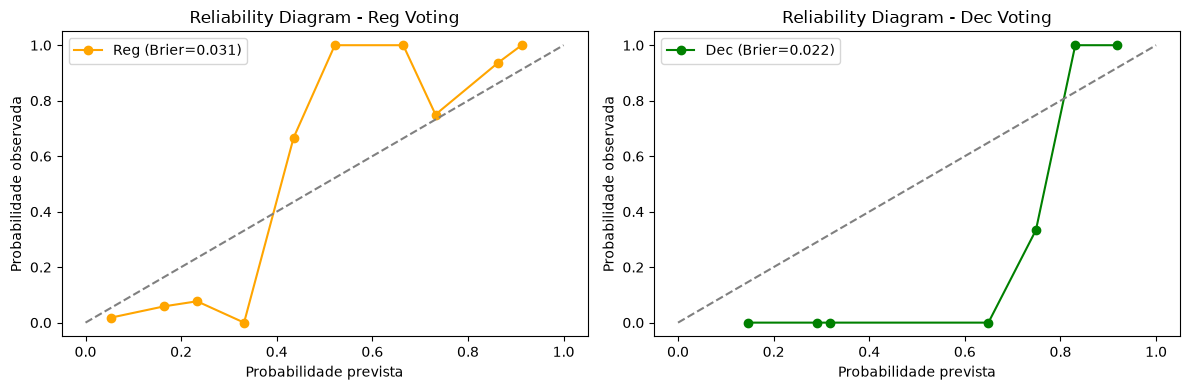

In [38]:
# --- Reliability diagram (diagrama de calibração) ---
# Probabilidades no conjunto de teste (calibradas)
probs_reg_test = reg_trained.predict_proba(X_teste)[:, 1]
probs_dec_test = dec_trained.predict_proba(X_teste)[:, 1]

# Curvas de calibração
prob_true_reg, prob_pred_reg = calibration_curve(y_teste, probs_reg_test, n_bins=10)
prob_true_dec, prob_pred_dec = calibration_curve(y_teste, probs_dec_test, n_bins=10)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(prob_pred_reg, prob_true_reg, marker='o', color='orange', label=f'Reg (Brier={brier_score_loss(y_teste, probs_reg_test):.3f})')
ax[0].plot([0, 1], [0, 1], '--', color='gray')
ax[0].set_title('Reliability Diagram - Reg Voting')
ax[0].set_xlabel('Probabilidade prevista')
ax[0].set_ylabel('Probabilidade observada')
ax[0].legend()

ax[1].plot(prob_pred_dec, prob_true_dec, marker='o', color='green', label=f'Dec (Brier={brier_score_loss(y_teste, probs_dec_test):.3f})')
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_title('Reliability Diagram - Dec Voting')
ax[1].set_xlabel('Probabilidade prevista')
ax[1].set_ylabel('Probabilidade observada')
ax[1].legend()

plt.tight_layout()
plt.show()

Voting Regressão Logística
Accuracy: 0.9730

Voting Árvore de Decisão
Accuracy: 0.9899



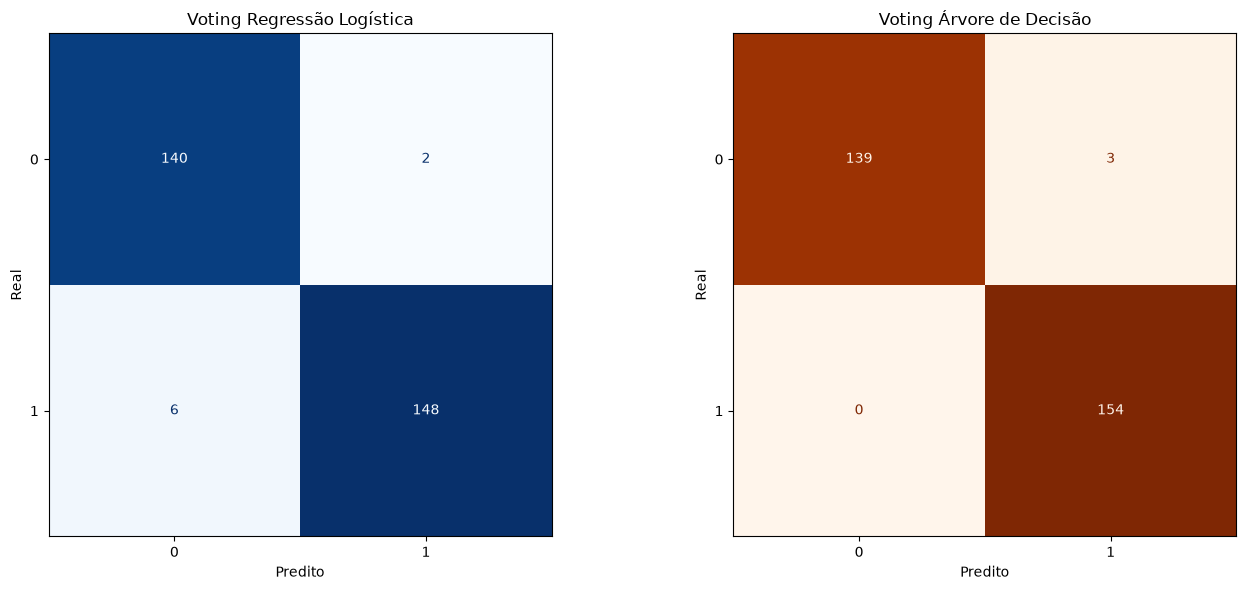

In [39]:
# Matriz de Confusão para cada modelo Voting

models = [
    ('Voting Regressão Logística', reg_trained, 'Blues'),
    ('Voting Árvore de Decisão', dec_trained, 'Oranges')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model, cmap) in zip(axes, models):
    y_pred = model.predict(X_teste)
    cm = confusion_matrix(y_teste, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

    accuracy = accuracy_score(y_teste, y_pred)
    print(f"{name}")
    print(f"Accuracy: {accuracy:.4f}\n")

plt.tight_layout()
plt.show()

In [105]:
reg_trained = dict_melhores_modelos["LOG_REGS"]

# Acessar os coeficientes e o intercepto
pesos = reg_trained.coef_
vies = reg_trained.intercept_

print(f"Pesos (w): {pesos}")
print(f"Viés (b): {vies}")



Pesos (w): [[0.1392072  0.33803083]]
Viés (b): [-22.40163142]
